# Forward simulation — 8-input-source structure

Visualizes the structure's initial design, runs the modular forward-simulation
solver (`forward_simulation/`) on real force data from the co-optimization
training dataset, and sanity-checks the result against the originally
recorded response for the same force.

In [1]:
from pathlib import Path
import sys

import numpy as np
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data"

from forward_simulation.structures import build_input_source_8
from forward_simulation.solver import build_forward_problem
from blockymetamaterials.plotting_input import plot_geometry

# Default setting
import matplotlib as mpl
import matplotlib
from matplotlib import cm
from cycler import cycler

# mpl.rcParams['axes.prop_cycle'] = cycler(color='brgcmyk')
# grid setting
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.color'] = '#808080'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

# graph font size
# mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

# tight axis
plt.rcParams['axes.xmargin'] = 0

# figure size
plt.rcParams["figure.figsize"] = (6.4, 4.8)

# LaTeX
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['pdf.fonttype'] = 42 # For TrueType fonts

COLORS = ["#cc3f40", "#bdccd4", "#0b2456", "#2980b9", "#00a043"]

## Initial design

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


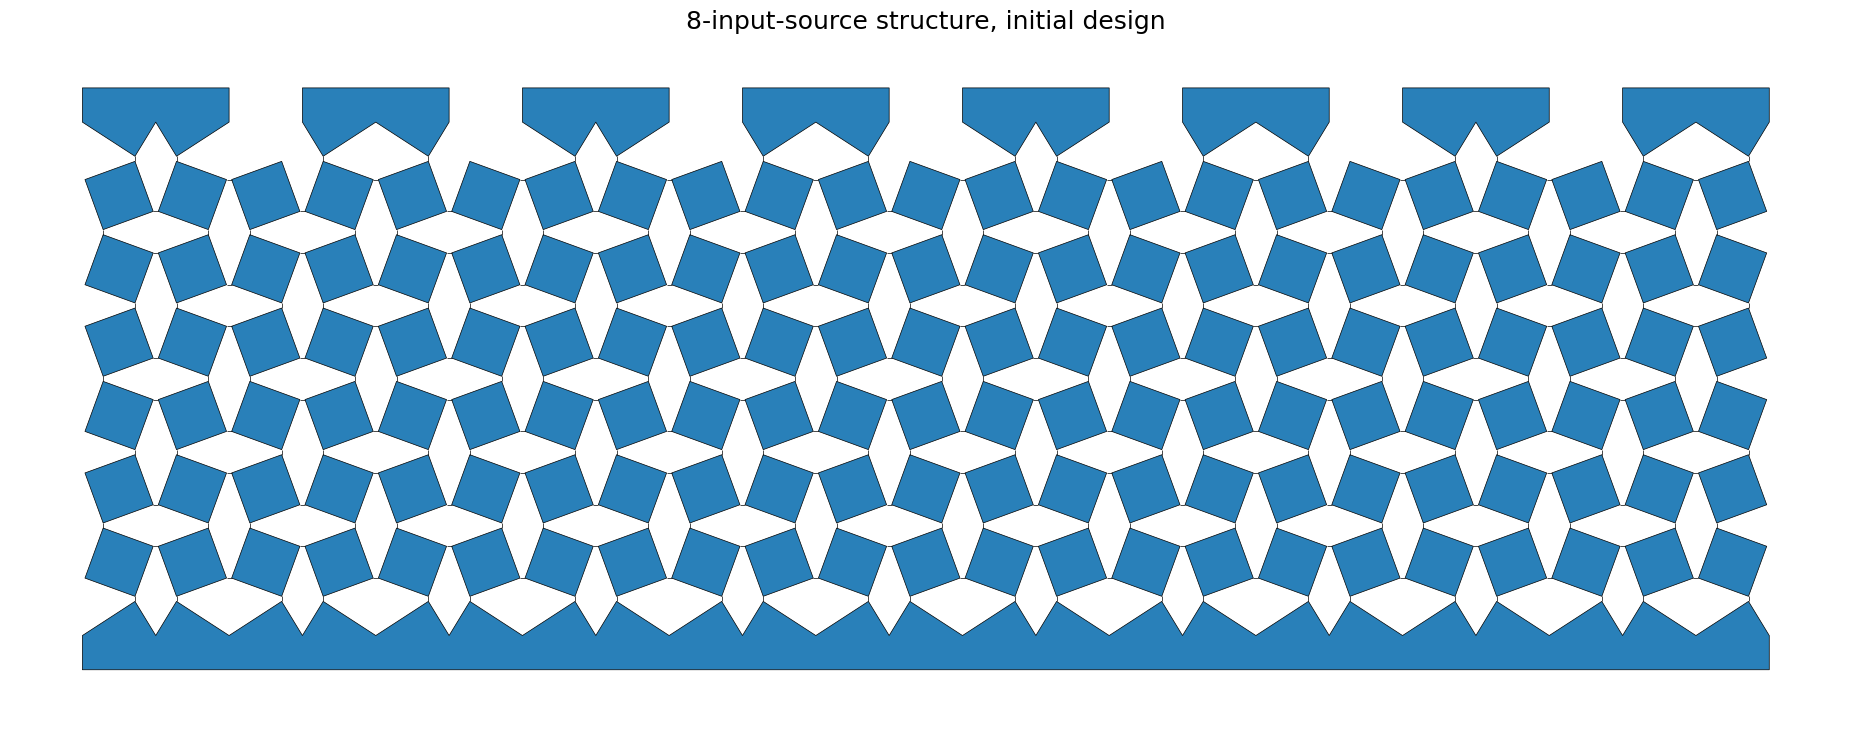

In [2]:
structure = build_input_source_8()
geometry = structure.geometry
h, v = structure.initial_design

xlim, ylim = geometry.get_xy_limits(h, v) + 0.5 * geometry.spacing * jnp.array([-1, 1])
fig, ax = plot_geometry(
    block_centroids=geometry.block_centroids(h, v),
    centroid_node_vectors=geometry.centroid_node_vectors(h, v),
    bond_connectivity=geometry.bond_connectivity(),
    xlim=xlim, ylim=ylim, figsize=(4 * structure.geometry.n1_blocks / 5, 6 * structure.geometry.n2_blocks / 5),
)
ax.axis("off")
ax.set_title("8-input-source structure, initial design")
plt.show()

## Load co-optimization force data and run the forward simulation

In [3]:
data = np.load(DATA_DIR / "forward_sim_input_source_8.npz")
time = data["time"]
output_data = jnp.asarray(data["output_data"])   # force driving the simulation, (N, T, 8)
recorded_input_data = data["input_data"]          # originally recorded response, (N, T, 3)
print("output_data (force):", output_data.shape)
print("recorded input_data (response):", recorded_input_data.shape)

output_data (force): (30, 200, 8)
recorded input_data (response): (30, 200, 3)


In [4]:
forward_problem = build_forward_problem(structure)
run_batch = vmap(forward_problem, in_axes=(None, 0))
new_input_data = np.asarray(run_batch(structure.initial_design, output_data))
print("new_input_data:", new_input_data.shape)

new_input_data: (30, 200, 3)


## Sanity check: new simulation vs. originally recorded response

relative error per sample [%]: median=5.988e-11, mean=1.410e-10, max=1.147e-09


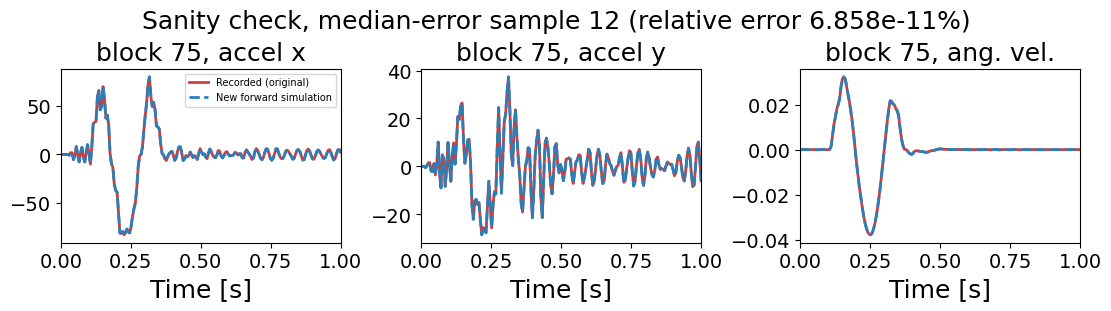

In [5]:
rel_err = np.sum((new_input_data - recorded_input_data) ** 2, axis=(1, 2)) / np.sum(recorded_input_data ** 2, axis=(1, 2)) * 100.0
print(f"relative error per sample [%]: median={np.median(rel_err):.3e}, mean={rel_err.mean():.3e}, max={rel_err.max():.3e}")
sample = int(np.argsort(rel_err)[len(rel_err) // 2])

n_measure = len(structure.measure_idx)
channel_labels = ["accel x", "accel y", "ang. vel."]
fig, axes = plt.subplots(n_measure, 3, figsize=(11, 3 * n_measure), constrained_layout=True, squeeze=False)
for m in range(n_measure):
    for ch in range(3):
        ax = axes[m, ch]
        col = m * 3 + ch
        ax.plot(time, recorded_input_data[sample, :, col], color=COLORS[0], label="Recorded (original)")
        ax.plot(time, new_input_data[sample, :, col], color=COLORS[3], linestyle="--", label="New forward simulation")
        ax.set_title(f"block {int(structure.measure_idx[m])}, {channel_labels[ch]}")
        if m == n_measure - 1:
            ax.set_xlabel("Time [s]")
axes[0, 0].legend(loc="upper right", fontsize=7)
fig.suptitle(f"Sanity check, median-error sample {sample} (relative error {rel_err[sample]:.3e}%)")
plt.show()